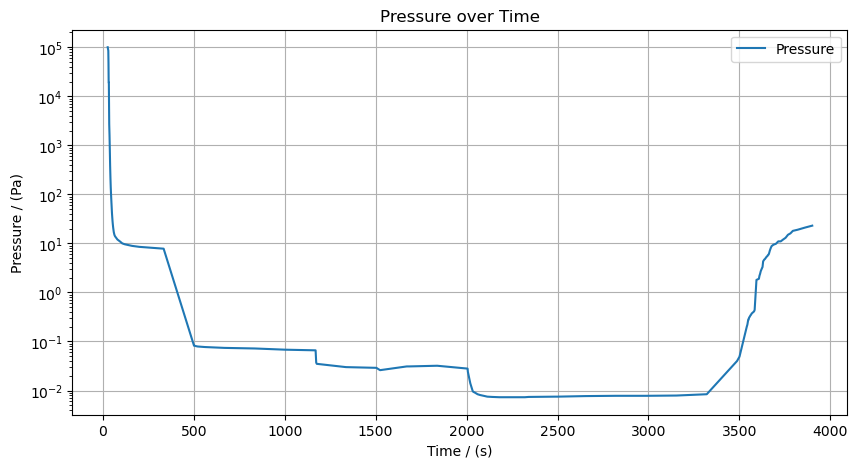

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设你的Excel文件名为data.xlsx，时间列名为'Time'，气压列名为'Pressure'
file_name = 'Pressure-time_data.xlsx'
time_column = '时间(s)'
pressure_column = '压强(Pa)'

# 读取Excel文件
df = pd.read_excel(file_name)

# 确保时间列是datetime类型
# df[time_column] = pd.to_datetime(df[time_column])

# 绘制时序图
plt.figure(figsize=(10, 5))
plt.plot(df[time_column], df[pressure_column], label='Pressure')
plt.title('Pressure over Time')
plt.xlabel('Time / (s)')
plt.ylabel('Pressure / (Pa)')
# plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

c:\Users\TaLEsCuber\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\TaLEsCuber\AppData\Local\Temp\ipykernel_137312\1631178765.py:10: RuntimeWarning: invalid value encountered in log
  return (B * p * d) / (np.log((A * p * d) / (np.log(1 + 1 / gamma))))


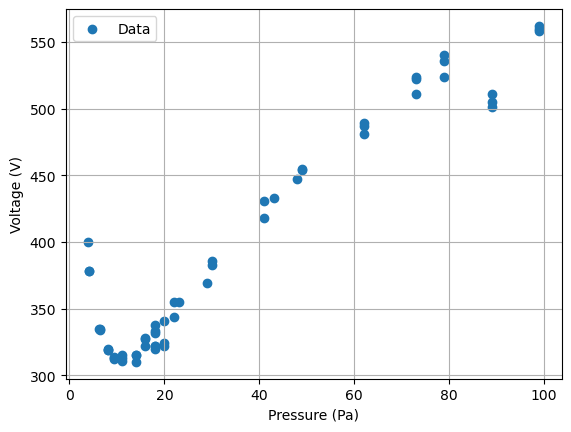

拟合参数: B = 394.088, A = 17.123, gamma = 0.036
拟合的R²值: 0.060


In [3]:
from scipy.optimize import curve_fit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d = 0.06  # 电极间距

# 帕邢定律模型函数
def func(p, B, A, gamma):
    return (B * p * d) / (np.log((A * p * d) / (np.log(1 + 1 / gamma))))

# 读取数据
df2 = pd.read_excel("Paschen's_law.xlsx")

y_data = df2['击穿电压']
x_data = df2['气压']

# 设置参数的初值
initial_guess = [500, 100, 0.6]  # 这里需要根据实际情况调整初值

# 使用curve_fit进行拟合，并指定初值
params, covariance = curve_fit(func, x_data, y_data, p0 = initial_guess)

# 提取拟合参数
B, A, gamma = params

# 使用拟合参数计算拟合值
y_fit = func(x_data, B, A, gamma)

# 计算R-squared
residuals = y_data - y_fit  # 残差
ss_res = np.sum(residuals**2)  # 残差平方和
ss_tot = np.sum((y_data - np.mean(y_data))**2)  # 总平方和
r_squared = 1 - (ss_res / ss_tot)  # 计算R-squared

# 使用拟合参数绘制拟合曲线
x_fit = np.linspace(min(x_data), max(x_data), 1000)
y_fit_curve = func(x_fit, B, A, gamma)

# 绘制原始数据点
plt.scatter(x_data, y_data, label='Data')

# 绘制拟合曲线
# plt.plot(x_fit, y_fit_curve, label=f'Fit: B={B:.3f}, A={A:.3f}, gamma={gamma:.3f}, R²={r_squared:.3f}')

# 设置图形标签
plt.xlabel('Pressure (Pa)')
plt.ylabel('Voltage (V)')

# 绘制网格和图例
plt.grid()
plt.legend()

# 显示图形
plt.show()

# 输出拟合的参数和R²值
print(f"拟合参数: B = {B:.3f}, A = {A:.3f}, gamma = {gamma:.3f}")
print(f"拟合的R²值: {r_squared:.3f}")


In [4]:
import numpy as np
print("Covariance matrix:\n", covariance)
print("Parameter errors:\n", np.sqrt(np.diag(covariance)))

Covariance matrix:
 [[ 1.93927996e+02  9.12905109e+07 -6.66041040e+05]
 [ 9.12905109e+07  4.93569467e+14 -3.60100441e+12]
 [-6.66041040e+05 -3.60100441e+12  2.62723561e+10]]
Parameter errors:
 [1.39258032e+01 2.22164234e+07 1.62087495e+05]


c:\Users\TaLEsCuber\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\TaLEsCuber\AppData\Local\Temp\ipykernel_137312\640051880.py:11: RuntimeWarning: invalid value encountered in log
  log_term = np.log((A * p * d) / (np.log(1 + 1 / gamma)))


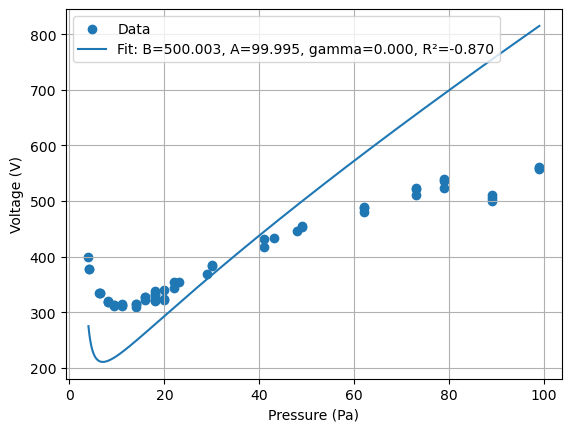

拟合参数: B = 500.003, A = 99.995, gamma = 0.000
拟合的R²值: -0.870


In [5]:
from scipy.optimize import least_squares
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d = 0.06  # 电极间距

# 帕邢定律模型函数
def func(p, B, A, gamma):
    # 计算过程中加入检查，确保log函数不会遇到负数或零
    log_term = np.log((A * p * d) / (np.log(1 + 1 / gamma)))
    if np.any(log_term <= 0):  # 如果log的结果<=0，避免计算错误
        return np.full_like(p, np.nan)  # 返回NaN，表示该点无效
    return (B * p * d) / log_term

# 读取数据
df2 = pd.read_excel("Paschen's_law.xlsx")

y_data = df2['击穿电压']
x_data = df2['气压']

# 检查数据中是否有无效的值
if np.any(x_data <= 0) or np.any(y_data <= 0):
    print("警告：数据中包含无效值（<=0），请检查数据!")

# 初始参数猜测值
initial_guess = [500, 100, 0.6]

# 使用least_squares进行鲁棒拟合
result = least_squares(lambda p: func(x_data, *p) - y_data, initial_guess, loss='huber', f_scale=1.0)

# 提取拟合参数
B, A, gamma = result.x

# 使用拟合参数计算拟合值
y_fit = func(x_data, B, A, gamma)

# 计算R-squared
residuals = y_data - y_fit  # 残差
ss_res = np.sum(residuals**2)  # 残差平方和
ss_tot = np.sum((y_data - np.mean(y_data))**2)  # 总平方和
r_squared = 1 - (ss_res / ss_tot)  # 计算R-squared

# 使用拟合参数绘制拟合曲线
x_fit = np.linspace(min(x_data), max(x_data), 1000)
y_fit_curve = func(x_fit, B, A, gamma)

# 绘制原始数据点
plt.scatter(x_data, y_data, label='Data')

# 绘制拟合曲线
plt.plot(x_fit, y_fit_curve, label=f'Fit: B={B:.3f}, A={A:.3f}, gamma={gamma:.3f}, R²={r_squared:.3f}')

# 设置图形标签
plt.xlabel('Pressure (Pa)')
plt.ylabel('Voltage (V)')

# 绘制网格和图例
plt.grid()
plt.legend()

# 显示图形
plt.show()

# 输出拟合的参数和R²值
print(f"拟合参数: B = {B:.3f}, A = {A:.3f}, gamma = {gamma:.3f}")
print(f"拟合的R²值: {r_squared:.3f}")


拟合得到的参数:
A = 7.017566212424544
B = 394.08946175091967
gamma = 0.33734775891253405
相关系数: 0.9737422191180282


<>:44: SyntaxWarning: invalid escape sequence '\g'
<>:44: SyntaxWarning: invalid escape sequence '\g'
C:\Users\TaLEsCuber\AppData\Local\Temp\ipykernel_137312\3272074236.py:44: SyntaxWarning: invalid escape sequence '\g'
  plt.plot(x_plotting, voltage_fit, label=f"fitting curve \n$R^2 = {corr_coefficient:5.3}$, A = {params[0]:5.3}, B = {params[1]:5.3}, $\gamma$ = {params[2]:5.3}", color='red', linewidth=2)
C:\Users\TaLEsCuber\AppData\Local\Temp\ipykernel_137312\3272074236.py:18: RuntimeWarning: invalid value encountered in log
  return (B * p * d) / (np.log(A * p * d) - np.log(np.log(1 + 1 / gamma)))


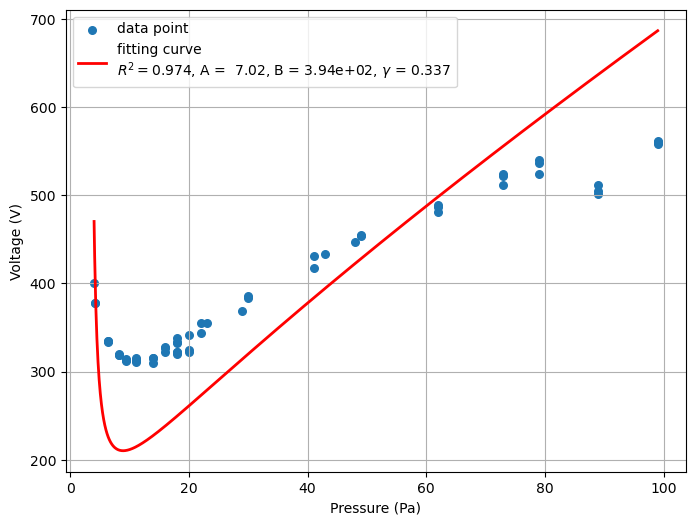

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

# 假设你的气压数据和击穿电压数据分别存储在压力（pressure）和电压（voltage）两个列表中
pressure = df2['气压']  # 替换为你的气压数据
voltage =  df2['击穿电压']  # 替换为你的击穿电压数据



d = 0.06 # m

gamma = 0.6

# 定义帕邢定律的拟合函数
def paschen_law(p, A, B, gamma):
    return (B * p * d) / (np.log(A * p * d) - np.log(np.log(1 + 1 / gamma)))

# 初始猜测的参数值 A, B, d, gamma
initial_guess = [10, 400, 0.6]

# 使用 curve_fit 进行参数拟合
params, covariance = curve_fit(paschen_law, pressure, voltage, p0=initial_guess)

# 拟合的参数
A_fit, B_fit, gamma_fit = params
print(f"拟合得到的参数:\nA = {A_fit}\nB = {B_fit}\ngamma = {gamma_fit}")

# 使用拟合得到的参数来计算拟合的电压

x_plotting = np.linspace(min(pressure), max(pressure), 1000)
voltage_fit = paschen_law(x_plotting, *params)

voltage_calculate = paschen_law(pressure, *params)
# 计算相关系数
corr_coefficient, _ = pearsonr(voltage, voltage_calculate)
print(f"相关系数: {corr_coefficient}")

# 绘制原始数据和拟合结果
plt.figure(figsize=(8, 6))
plt.scatter(pressure, voltage, label="data point", s=30)

plt.plot(x_plotting, voltage_fit, label=f"fitting curve \n$R^2 = {corr_coefficient:5.3}$, A = {params[0]:5.3}, B = {params[1]:5.3}, $\gamma$ = {params[2]:5.3}", color='red', linewidth=2)
plt.xlabel("Pressure (Pa)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.grid()
plt.show()





c:\Users\TaLEsCuber\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36724 (\N{CJK UNIFIED IDEOGRAPH-8F74}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\TaLEsCuber\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\TaLEsCuber\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\TaLEsCuber\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\TaLEsCuber\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from current font.
  fig.c

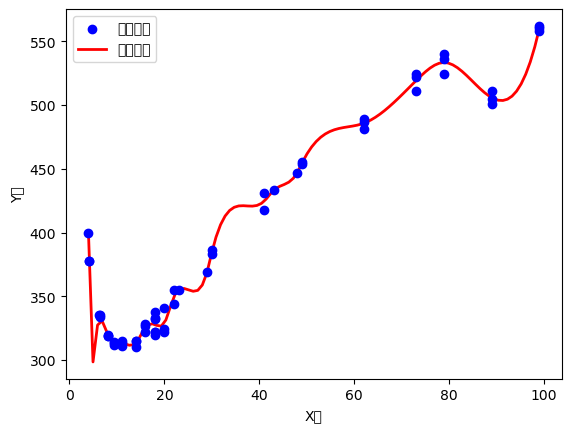

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 示例数据：x中有重复值
x = df2['气压'] 
y = df2['击穿电压']

# 对重复的x值进行聚合（比如取均值）
unique_x = np.unique(x)  # 获取唯一的x值
aggregated_y = [np.mean(y[x == ux]) for ux in unique_x]  # 对重复的y值求平均

# 使用立方样条插值生成平滑曲线
cs = CubicSpline(unique_x, aggregated_y)

# 创建插值点
x_new = np.linspace(unique_x.min(), unique_x.max(), 100)  # 在x的范围内生成100个点
y_new = cs(x_new)  # 计算插值后的y值

# 绘制原始数据和拟合结果
plt.scatter(x, y, label="原始数据", color='blue', zorder=5)
plt.plot(x_new, y_new, label="平滑曲线", color='red', linewidth=2)
plt.xlabel("X轴")
plt.ylabel("Y轴")
plt.legend()
plt.show()


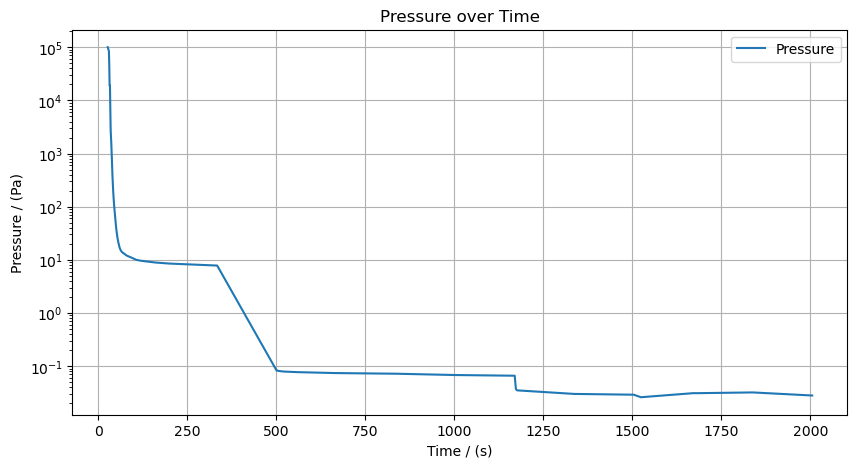

In [119]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设你的Excel文件名为data.xlsx，时间列名为'Time'，气压列名为'Pressure'
file_name = 'Pressure-time_data.xlsx'
time_column = '时间(s)'
pressure_column = '压强(Pa)'

# 读取Excel文件
df = pd.read_excel(file_name, sheet_name='Sheet1')

# 确保时间列是datetime类型
# df[time_column] = pd.to_datetime(df[time_column])

# 绘制时序图
plt.figure(figsize=(10, 5))
plt.plot(df[time_column], df[pressure_column], label='Pressure')
plt.title('Pressure over Time')
plt.xlabel('Time / (s)')
plt.ylabel('Pressure / (Pa)')
# plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

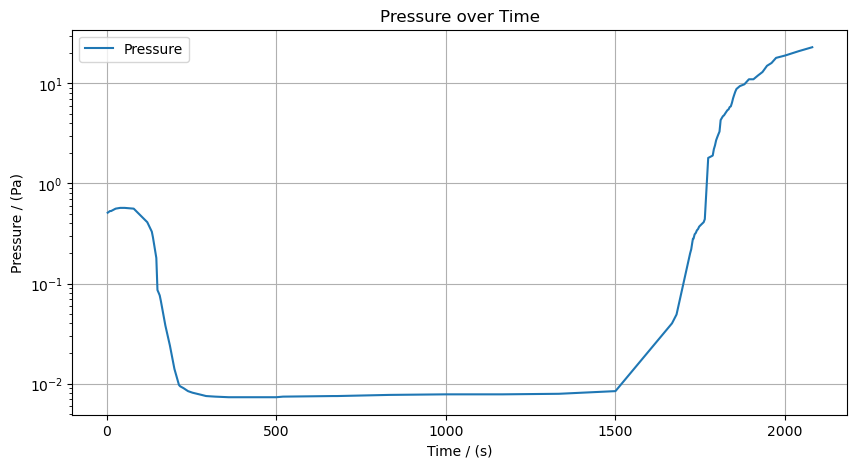

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设你的Excel文件名为data.xlsx，时间列名为'Time'，气压列名为'Pressure'
file_name = 'Pressure-time_data.xlsx'
time_column = '时间(s)'
pressure_column = '压强(Pa)'

# 读取Excel文件
df = pd.read_excel(file_name, sheet_name='Sheet2')

# 确保时间列是datetime类型
# df[time_column] = pd.to_datetime(df[time_column])

# 绘制时序图
plt.figure(figsize=(10, 5))
plt.plot(df[time_column], df[pressure_column], label='Pressure')
plt.title('Pressure over Time')
plt.xlabel('Time / (s)')
plt.ylabel('Pressure / (Pa)')
# plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

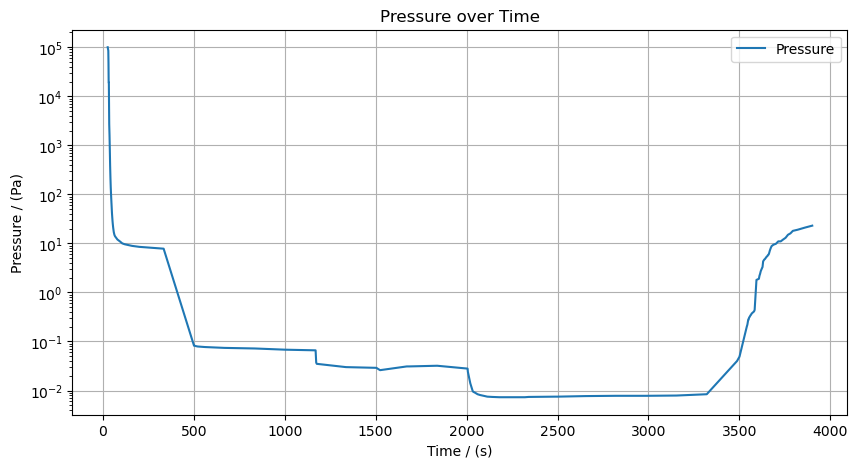

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设你的Excel文件名为data.xlsx，时间列名为'Time'，气压列名为'Pressure'
file_name = 'Pressure-time_data.xlsx'
time_column = '时间(s)'
pressure_column = '压强(Pa)'

# 读取Excel文件
df = pd.read_excel(file_name, sheet_name='Sheet1')
# df2 = pd.read_excel(file_name, sheet_name='Sheet2')

# df2[time_column] = df2[time_column] + df1[time_column].iloc[-1]

# df = pd.concat([df1, df2], ignore_index=True)

# 确保时间列是datetime类型
# df[time_column] = pd.to_datetime(df[time_column])

# 绘制时序图
plt.figure(figsize=(10, 5))
plt.plot(df[time_column], df[pressure_column], label='Pressure')
plt.title('Pressure over Time')
plt.xlabel('Time / (s)')
plt.ylabel('Pressure / (Pa)')
# plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()